In [2]:
!pip install xsuite


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 759.1/759.1 kB 42.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.2/240.2 kB 27.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.8/77.8 kB 8.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 5.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 95.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/

In [ ]:
from __future__ import annotations

import argparse
import json
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Literal, Optional, Tuple

import numpy as np
import xtrack as xt

/usr/local/lib/python3.12/dist-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [4]:
PHASE_SPACE_DIM = 6
PHASE_SPACE_LABELS = ("x", "y", "zeta", "px", "py", "delta")


@dataclass
class BeamFamilyConfig:
    family: Literal[
        "gaussian",
        "correlated_gaussian",
        "core_halo",
        "mixture",
        "mismatched"
    ]
    x_sigma: float = 1e-3
    y_sigma: float = 1e-3
    zeta_sigma: float = 1e-3
    px_sigma: float = 1e-3
    py_sigma: float = 1e-3
    delta_sigma: float = 1e-4
    halo_scale: float = 4.0
    halo_fraction: float = 0.15
    mismatch_scale: float = 2.0
    corr_strength: float = 0.45
    mixture_shift_scale: float = 1.2


@dataclass
class LatticeConfig:
    p0c_ev: float = 1e9
    mass0_ev: float = xt.PROTON_MASS_EV
    l_mq: float = 0.4
    line_length: float = 4.0
    qf1_at: float = 1.0
    qd1_at: float = 2.0
    qf2_at: float = 3.0


@dataclass
class ParameterRanges:
    kf1_range: Tuple[float, float] = (0.1, 2.0)
    kd1_range: Tuple[float, float] = (-4.5, -0.05)
    kf2_range: Tuple[float, float] = (0.1, 2.0)


@dataclass
class DensityGridConfig:
    nz: int = 256
    zeta_min: float = -5e-3
    zeta_max: float = 5e-3
    normalize_density: bool = True


@dataclass
class DatasetConfig:
    n_samples: int = 512
    particles_per_sample: int = 4096
    seed: int = 42
    output_dir: str = "./data/neural"
    save_cloud_dataset: bool = True
    save_density_dataset: bool = True
    save_moments: bool = True
    train_fraction: float = 0.8
    val_fraction: float = 0.1


def build_line(lattice_cfg: LatticeConfig) -> Tuple[xt.Line, xt.Environment]:
    """Build a simple Xsuite line with three quadrupoles."""
    part_ref = xt.Particles(mass0=lattice_cfg.mass0_ev, p0c=lattice_cfg.p0c_ev)

    env = xt.Environment()
    env.vars.default_to_zero = True
    env["l_mq"] = lattice_cfg.l_mq

    env.new("mq", xt.Quadrupole, length="l_mq")
    env.new("qf1", "mq", k1="kf1")
    env.new("qd1", "mq", k1="kd1")
    env.new("qf2", "mq", k1="kf2")
    env.new("start_cell", xt.Marker)
    env.new("end_cell", xt.Marker)

    line = env.new_line(
        length=lattice_cfg.line_length,
        components=[
            env.place("start_cell", at=0.0),
            env.place("qf1", at=lattice_cfg.qf1_at),
            env.place("qd1", at=lattice_cfg.qd1_at),
            env.place("qf2", at=lattice_cfg.qf2_at),
            env.place("end_cell", at=lattice_cfg.line_length),
        ],
    )
    line.particle_ref = part_ref
    line.build_tracker()
    return line, env


def _diag_sigmas(cfg: BeamFamilyConfig) -> np.ndarray:
    return np.array(
        [
            cfg.x_sigma,
            cfg.y_sigma,
            cfg.zeta_sigma,
            cfg.px_sigma,
            cfg.py_sigma,
            cfg.delta_sigma,
        ],
        dtype=np.float64,
    )


def sample_initial_conditions(
    n_particles: int,
    rng: np.random.Generator,
    beam_cfg: BeamFamilyConfig,
) -> np.ndarray:
    """Sample a particle cloud in R^6.

    Output order is [x, y, zeta, px, py, delta].
    """
    sigmas = _diag_sigmas(beam_cfg)

    if beam_cfg.family == "gaussian":
        z = rng.normal(0.0, sigmas, size=(n_particles, PHASE_SPACE_DIM))
        return z.astype(np.float64)

    if beam_cfg.family == "correlated_gaussian":
        cov = np.diag(sigmas ** 2)
        # modest correlations in each plane
        corr = beam_cfg.corr_strength
        cov[0, 3] = cov[3, 0] = corr * sigmas[0] * sigmas[3]
        cov[1, 4] = cov[4, 1] = corr * sigmas[1] * sigmas[4]
        cov[2, 5] = cov[5, 2] = corr * sigmas[2] * sigmas[5]
        z = rng.multivariate_normal(np.zeros(PHASE_SPACE_DIM), cov, size=n_particles)
        return z.astype(np.float64)

    if beam_cfg.family == "core_halo":
        n_halo = int(round(beam_cfg.halo_fraction * n_particles))
        n_core = n_particles - n_halo
        core = rng.normal(0.0, sigmas, size=(n_core, PHASE_SPACE_DIM))
        halo = rng.normal(0.0, beam_cfg.halo_scale * sigmas, size=(n_halo, PHASE_SPACE_DIM))
        z = np.vstack([core, halo])
        rng.shuffle(z, axis=0)
        return z.astype(np.float64)

    if beam_cfg.family == "mixture":
        shift = beam_cfg.mixture_shift_scale * sigmas
        n_a = n_particles // 2
        n_b = n_particles - n_a
        a = rng.normal(-shift, sigmas, size=(n_a, PHASE_SPACE_DIM))
        b = rng.normal(+shift, sigmas, size=(n_b, PHASE_SPACE_DIM))
        z = np.vstack([a, b])
        rng.shuffle(z, axis=0)
        return z.astype(np.float64)

    if beam_cfg.family == "mismatched":
        scaled = np.array(sigmas)
        scaled[[0, 1, 3, 4]] *= beam_cfg.mismatch_scale
        z = rng.normal(0.0, scaled, size=(n_particles, PHASE_SPACE_DIM))
        return z.astype(np.float64)

    raise ValueError(f"Unsupported beam family: {beam_cfg.family}")


def particles_to_6d(particles: xt.Particles) -> np.ndarray:
    return np.column_stack(
        [
            np.asarray(particles.x),
            np.asarray(particles.y),
            np.asarray(particles.zeta),
            np.asarray(particles.px),
            np.asarray(particles.py),
            np.asarray(particles.delta),
        ]
    ).astype(np.float64)


def sample_parameters(
    rng: np.random.Generator,
    param_ranges: ParameterRanges,
) -> np.ndarray:
    return np.array(
        [
            rng.uniform(*param_ranges.kf1_range),
            rng.uniform(*param_ranges.kd1_range),
            rng.uniform(*param_ranges.kf2_range),
        ],
        dtype=np.float64,
    )


def set_lattice_parameters(env: xt.Environment, mu: np.ndarray) -> None:
    env["kf1"] = float(mu[0])
    env["kd1"] = float(mu[1])
    env["kf2"] = float(mu[2])


def track_cloud(line: xt.Line, z0: np.ndarray) -> np.ndarray:
    p = line.build_particles(
        x=z0[:, 0],
        y=z0[:, 1],
        zeta=z0[:, 2],
        px=z0[:, 3],
        py=z0[:, 4],
        delta=z0[:, 5],
    )
    line.track(p)
    return particles_to_6d(p)


def cloud_moments(z: np.ndarray) -> Dict[str, np.ndarray]:
    centroid = z.mean(axis=0)
    cov = np.cov(z, rowvar=False)
    return {"centroid": centroid, "cov": cov}


def line_density_from_cloud(
    z: np.ndarray,
    density_cfg: DensityGridConfig,
) -> Tuple[np.ndarray, np.ndarray]:
    """Return (bin_centers, normalized_histogram) for zeta marginal."""
    hist, edges = np.histogram(
        z[:, 2],
        bins=density_cfg.nz,
        range=(density_cfg.zeta_min, density_cfg.zeta_max),
        density=False,
    )
    centers = 0.5 * (edges[:-1] + edges[1:])
    hist = hist.astype(np.float64)
    if density_cfg.normalize_density:
        dz = (density_cfg.zeta_max - density_cfg.zeta_min) / density_cfg.nz
        norm = hist.sum() * dz
        if norm > 0:
            hist = hist / norm
    return centers, hist


def build_datasets(
    line: xt.Line,
    env: xt.Environment,
    dataset_cfg: DatasetConfig,
    density_cfg: DensityGridConfig,
    param_ranges: ParameterRanges,
    beam_families: Iterable[BeamFamilyConfig],
) -> Dict[str, np.ndarray]:
    rng = np.random.default_rng(dataset_cfg.seed)
    families = list(beam_families)
    if not families:
        raise ValueError("At least one beam family must be provided.")

    cloud_in, cloud_out, mu_all = [], [], []
    lambda_in, lambda_out, zeta_grid = [], [], None
    moments_in_centroid, moments_out_centroid = [], []
    moments_in_cov, moments_out_cov = [], []
    family_id = []

    for _ in range(dataset_cfg.n_samples):
        beam_cfg = families[rng.integers(0, len(families))]
        mu = sample_parameters(rng, param_ranges)
        set_lattice_parameters(env, mu)

        z0 = sample_initial_conditions(dataset_cfg.particles_per_sample, rng, beam_cfg)
        z1 = track_cloud(line, z0)

        if dataset_cfg.save_cloud_dataset:
            cloud_in.append(z0.astype(np.float32))
            cloud_out.append(z1.astype(np.float32))
            mu_all.append(mu.astype(np.float32))

        if dataset_cfg.save_density_dataset:
            grid, lam0 = line_density_from_cloud(z0, density_cfg)
            _, lam1 = line_density_from_cloud(z1, density_cfg)
            zeta_grid = grid.astype(np.float32)
            lambda_in.append(lam0.astype(np.float32))
            lambda_out.append(lam1.astype(np.float32))

        if dataset_cfg.save_moments:
            m0 = cloud_moments(z0)
            m1 = cloud_moments(z1)
            moments_in_centroid.append(m0["centroid"].astype(np.float32))
            moments_out_centroid.append(m1["centroid"].astype(np.float32))
            moments_in_cov.append(m0["cov"].astype(np.float32))
            moments_out_cov.append(m1["cov"].astype(np.float32))

        family_id.append(beam_cfg.family)

    out: Dict[str, np.ndarray] = {}
    if cloud_in:
        out["X_cloud"] = np.stack(cloud_in, axis=0)
        out["Y_cloud"] = np.stack(cloud_out, axis=0)
        out["MU"] = np.stack(mu_all, axis=0)
    if lambda_in:
        out["zeta_grid"] = zeta_grid
        out["X_lambda"] = np.stack(lambda_in, axis=0)
        out["Y_lambda"] = np.stack(lambda_out, axis=0)
        if "MU" not in out:
            out["MU"] = np.stack(mu_all, axis=0)
    if moments_in_centroid:
        out["centroid_in"] = np.stack(moments_in_centroid, axis=0)
        out["centroid_out"] = np.stack(moments_out_centroid, axis=0)
        out["cov_in"] = np.stack(moments_in_cov, axis=0)
        out["cov_out"] = np.stack(moments_out_cov, axis=0)

    out["family_id"] = np.array(family_id)
    return out


def split_indices(
    n: int,
    train_fraction: float,
    val_fraction: float,
    rng: np.random.Generator,
) -> Dict[str, np.ndarray]:
    if not (0 < train_fraction < 1):
        raise ValueError("train_fraction must be in (0, 1).")
    if not (0 <= val_fraction < 1):
        raise ValueError("val_fraction must be in [0, 1).")
    if train_fraction + val_fraction >= 1:
        raise ValueError("train_fraction + val_fraction must be < 1.")

    perm = rng.permutation(n)
    n_train = int(round(train_fraction * n))
    n_val = int(round(val_fraction * n))
    train_idx = perm[:n_train]
    val_idx = perm[n_train:n_train + n_val]
    test_idx = perm[n_train + n_val:]
    return {"train": train_idx, "val": val_idx, "test": test_idx}


def save_dataset_bundle(
    data: Dict[str, np.ndarray],
    dataset_cfg: DatasetConfig,
    density_cfg: DensityGridConfig,
    beam_families: Iterable[BeamFamilyConfig],
    param_ranges: ParameterRanges,
) -> None:
    out_dir = Path(dataset_cfg.output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    n_samples = None
    for key, value in data.items():
        if isinstance(value, np.ndarray) and value.ndim > 0 and value.shape[0] > 1 and key != "zeta_grid":
            n_samples = value.shape[0]
            break
    if n_samples is None:
        raise RuntimeError("Could not infer dataset size.")

    rng = np.random.default_rng(dataset_cfg.seed + 17)
    split = split_indices(n_samples, dataset_cfg.train_fraction, dataset_cfg.val_fraction, rng)

    np.savez(out_dir / "xsuite_neural_dataset.npz", **data, **split)

    metadata = {
        "phase_space_labels": PHASE_SPACE_LABELS,
        "dataset_config": asdict(dataset_cfg),
        "density_grid_config": asdict(density_cfg),
        "parameter_ranges": asdict(param_ranges),
        "beam_families": [asdict(b) for b in beam_families],
        "keys": sorted(list(data.keys()) + list(split.keys())),
    }
    (out_dir / "xsuite_neural_dataset_metadata.json").write_text(
        json.dumps(metadata, indent=2)
    )


def default_beam_families() -> List[BeamFamilyConfig]:
    return [
        BeamFamilyConfig(family="gaussian"),
        BeamFamilyConfig(family="correlated_gaussian"),
        BeamFamilyConfig(family="core_halo"),
        BeamFamilyConfig(family="mixture"),
        BeamFamilyConfig(family="mismatched"),
    ]


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Generate Xsuite datasets for neural operator learning.")
    parser.add_argument("--n-samples", type=int, default=512)
    parser.add_argument("--particles-per-sample", type=int, default=4096)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--output-dir", type=str, default="/data/neural")
    parser.add_argument("--nz", type=int, default=256)
    parser.add_argument("--zeta-min", type=float, default=-5e-3)
    parser.add_argument("--zeta-max", type=float, default=5e-3)
    parser.add_argument("--kf1-min", type=float, default=0.1)
    parser.add_argument("--kf1-max", type=float, default=2.0)
    parser.add_argument("--kd1-min", type=float, default=-4.5)
    parser.add_argument("--kd1-max", type=float, default=-0.05)
    parser.add_argument("--kf2-min", type=float, default=0.1)
    parser.add_argument("--kf2-max", type=float, default=2.0)
    parser.add_argument("--train-fraction", type=float, default=0.8)
    parser.add_argument("--val-fraction", type=float, default=0.1)
    parser.add_argument("--skip-cloud", action="store_true")
    parser.add_argument("--skip-density", action="store_true")
    return parser.parse_args()



In [7]:
args = argparse.Namespace(
    n_samples=512,
    particles_per_sample=10000,
    seed=42,
    output_dir="/data/neural",
    nz=256,
    zeta_min=-5e-3,
    zeta_max=5e-3,
    kf1_min=0.1,
    kf1_max=2.0,
    kd1_min=-4.5,
    kd1_max=-0.05,
    kf2_min=0.1,
    kf2_max=2.0,
    train_fraction=0.8,
    val_fraction=0.1,
    skip_cloud=False,
    skip_density=False,
)

In [8]:

lattice_cfg = LatticeConfig()
dataset_cfg = DatasetConfig(
        n_samples=args.n_samples,
        particles_per_sample=args.particles_per_sample,
        seed=args.seed,
        output_dir=args.output_dir,
        save_cloud_dataset=not args.skip_cloud,
        save_density_dataset=not args.skip_density,
        train_fraction=args.train_fraction,
        val_fraction=args.val_fraction,
    )
density_cfg = DensityGridConfig(
        nz=args.nz,
        zeta_min=args.zeta_min,
        zeta_max=args.zeta_max,
    )
param_ranges = ParameterRanges(
        kf1_range=(args.kf1_min, args.kf1_max),
        kd1_range=(args.kd1_min, args.kd1_max),
        kf2_range=(args.kf2_min, args.kf2_max),
    )
beam_families = default_beam_families()

line, env = build_line(lattice_cfg)
data = build_datasets(
        line=line,
        env=env,
        dataset_cfg=dataset_cfg,
        density_cfg=density_cfg,
        param_ranges=param_ranges,
        beam_families=beam_families,
    )
save_dataset_bundle(
        data=data,
        dataset_cfg=dataset_cfg,
        density_cfg=density_cfg,
        beam_families=beam_families,
        param_ranges=param_ranges,
    )

print("Saved dataset bundle to", dataset_cfg.output_dir)
for key, value in data.items():
    if isinstance(value, np.ndarray):
        print(f"  {key}: {value.shape} {value.dtype}")



Saved dataset bundle to /data/neural
  X_cloud: (512, 10000, 6) float32
  Y_cloud: (512, 10000, 6) float32
  MU: (512, 3) float32
  zeta_grid: (256,) float32
  X_lambda: (512, 256) float32
  Y_lambda: (512, 256) float32
  centroid_in: (512, 6) float32
  centroid_out: (512, 6) float32
  cov_in: (512, 6, 6) float32
  cov_out: (512, 6, 6) float32
  family_id: (512,) <U19


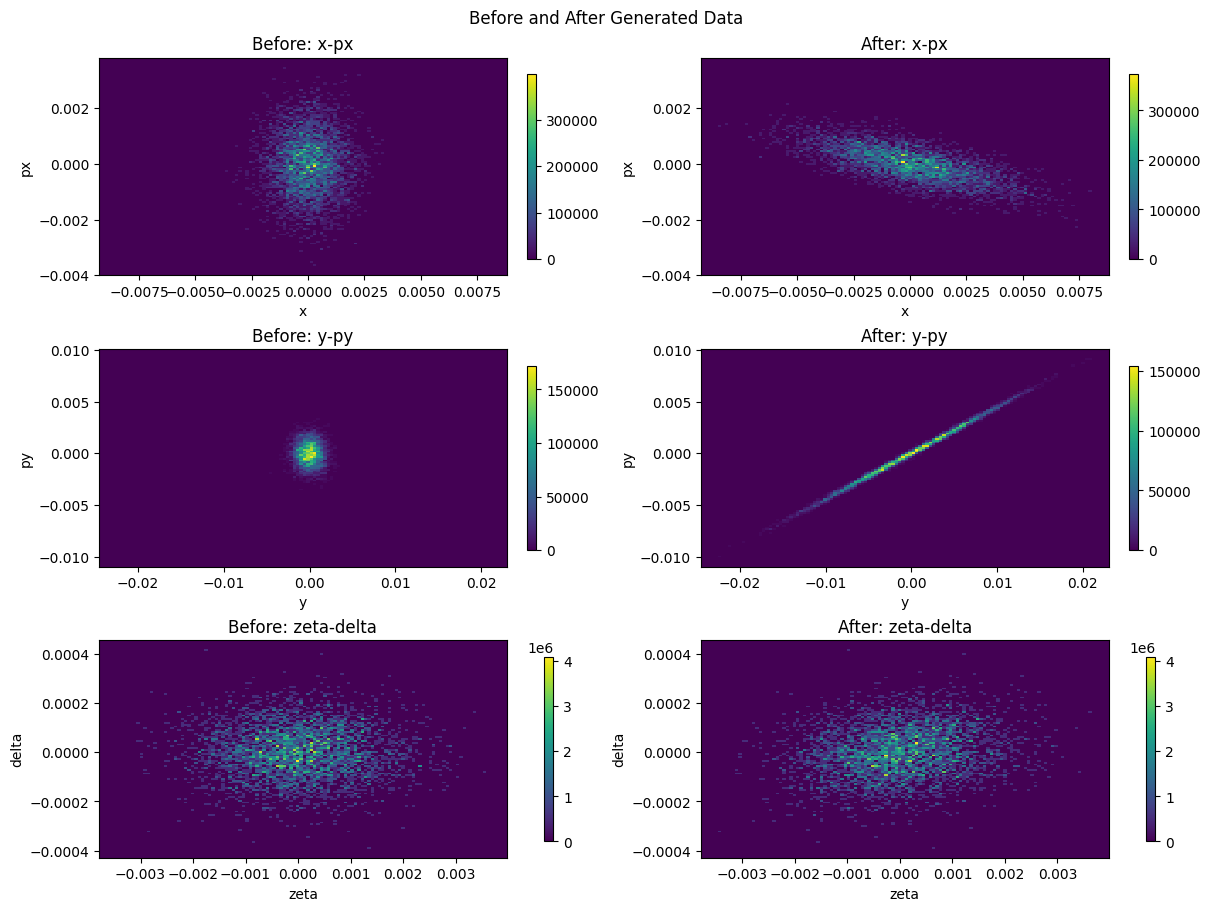

In [11]:
import matplotlib.pyplot as plt

def plot_example_distributions(i: int = 0, bins: int = 100, figsize: tuple = (12, 9),cmap = "viridis", title: str = "Before and After Generated Data") -> None:
    """
    Plot before/after 2D marginal histograms for the i-th example:
      - Row 1: x/px before (left) and after (right)
      - Row 2: y/py before (left) and after (right)
      - Row 3: zeta/delta before (left) and after (right)

    Expects data dict with keys "X_cloud" and "Y_cloud" present in the notebook.
    """
    if "X_cloud" not in data or "Y_cloud" not in data:
        raise RuntimeError("data must contain 'X_cloud' and 'Y_cloud' arrays")

    X = data["X_cloud"]  # shape (n_samples, n_particles, 6)
    Y = data["Y_cloud"]

    n_samples = X.shape[0]
    if not (0 <= i < n_samples):
        raise IndexError(f"i out of range (0 <= i < {n_samples})")

    z_before = X[i].astype(np.float64)  # (n_particles, 6)
    z_after = Y[i].astype(np.float64)

    projections = [
        (0, 3, "x", "px"),
        (1, 4, "y", "py"),
        (2, 5, "zeta", "delta"),
    ]

    fig, axes = plt.subplots(3, 2, figsize=figsize, constrained_layout=True)

    for row, (i, j, xl, yl) in enumerate(projections):
        all2 = np.vstack([z_before[:, [i, j]], z_after[:, [i, j]]])
        xpad = 0.05 * (all2[:, 0].max() - all2[:, 0].min() + 1e-15)
        ypad = 0.05 * (all2[:, 1].max() - all2[:, 1].min() + 1e-15)
        ranges = [
            [all2[:, 0].min() - xpad, all2[:, 0].max() + xpad],
            [all2[:, 1].min() - ypad, all2[:, 1].max() + ypad],
        ]

        im0 = axes[row, 0].hist2d(
            z_before[:, i], z_before[:, j],
            bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im0, ax=axes[row, 0], shrink=0.85)
        axes[row, 0].set_title(f"Before: {xl}-{yl}")
        axes[row, 0].set_xlabel(xl)
        axes[row, 0].set_ylabel(yl)

        im1 = axes[row, 1].hist2d(
            z_after[:, i], z_after[:, j],
            bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im1, ax=axes[row, 1], shrink=0.85)
        axes[row, 1].set_title(f"After: {xl}-{yl}")
        axes[row, 1].set_xlabel(xl)
        axes[row, 1].set_ylabel(yl)

    fig.suptitle(title)
    plt.show()


    

plot_example_distributions(i=0, bins=120)

In [12]:
from __future__ import annotations

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

In [13]:
@dataclass
class TrainConfig:
    dataset_path: str = "./data/neural/xsuite_neural_dataset.npz"
    batch_size: int = 16
    epochs: int = 100
    lr: float = 1e-3
    weight_decay: float = 1e-6
    width: int = 64
    modes: int = 16
    depth: int = 4
    hidden_proj: int = 128
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 42


class LambdaDataset(Dataset):
    def __init__(self, data: Dict[str, np.ndarray], split: str) -> None:
        self.x = data["X_lambda"][data[split]]
        self.y = data["Y_lambda"][data[split]]
        self.mu = data["MU"][data[split]]
        self.zeta_grid = data["zeta_grid"]

    def __len__(self) -> int:
        return self.x.shape[0]

    def __getitem__(self, idx: int):
        x = torch.from_numpy(self.x[idx]).float()          # [Nz]
        y = torch.from_numpy(self.y[idx]).float()          # [Nz]
        mu = torch.from_numpy(self.mu[idx]).float()        # [3]
        grid = torch.from_numpy(self.zeta_grid).float()    # [Nz]
        # channels: lambda_in, kf1, kd1, kf2, zeta
        features = torch.stack(
            [
                x,
                torch.full_like(x, mu[0]),
                torch.full_like(x, mu[1]),
                torch.full_like(x, mu[2]),
                grid,
            ],
            dim=-1,
        )  # [Nz, 5]
        return features, y


def load_npz(path: str) -> Dict[str, np.ndarray]:
    raw = np.load(path, allow_pickle=True)
    return {k: raw[k] for k in raw.files}


class SpectralConv1d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, modes: int) -> None:
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        scale = 1.0 / max(1, in_channels * out_channels)
        self.weight_real = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes)
        )
        self.weight_imag = nn.Parameter(
            scale * torch.randn(in_channels, out_channels, modes)
        )

    def compl_weight(self) -> torch.Tensor:
        return torch.complex(self.weight_real, self.weight_imag)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, C, N]
        batch, _, n = x.shape
        x_ft = torch.fft.rfft(x, dim=-1)
        n_modes = min(self.modes, x_ft.shape[-1])
        out_ft = torch.zeros(
            batch,
            self.out_channels,
            x_ft.shape[-1],
            dtype=torch.cfloat,
            device=x.device,
        )
        out_ft[:, :, :n_modes] = torch.einsum(
            "bim,iom->bom",
            x_ft[:, :, :n_modes],
            self.compl_weight()[:, :, :n_modes],
        )
        x = torch.fft.irfft(out_ft, n=n, dim=-1)
        return x


class FNOBlock1d(nn.Module):
    def __init__(self, width: int, modes: int) -> None:
        super().__init__()
        self.spectral = SpectralConv1d(width, width, modes)
        self.local = nn.Conv1d(width, width, kernel_size=1)
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.spectral(x) + self.local(x))


class FNO1d(nn.Module):
    def __init__(
        self,
        in_channels: int = 5,
        width: int = 64,
        modes: int = 16,
        depth: int = 4,
        hidden_proj: int = 128,
    ) -> None:
        super().__init__()
        self.lift = nn.Linear(in_channels, width)
        self.blocks = nn.ModuleList([FNOBlock1d(width, modes) for _ in range(depth)])
        self.proj1 = nn.Conv1d(width, hidden_proj, kernel_size=1)
        self.proj2 = nn.Conv1d(hidden_proj, 1, kernel_size=1)
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, N, C]
        x = self.lift(x)            # [B, N, W]
        x = x.permute(0, 2, 1)      # [B, W, N]
        for block in self.blocks:
            x = block(x)
        x = self.act(self.proj1(x))
        x = self.proj2(x)
        return x[:, 0, :]           # [B, N]


def relative_l2(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    num = torch.sum((pred - target) ** 2, dim=-1)
    den = torch.sum(target ** 2, dim=-1) + eps
    return torch.mean(torch.sqrt(num / den))


def line_density_mass(pred: torch.Tensor, grid: torch.Tensor) -> torch.Tensor:
    if grid.ndim != 1:
        raise ValueError("grid must be 1D")
    dz = (grid[-1] - grid[0]) / max(1, grid.numel() - 1)
    return torch.sum(pred, dim=-1) * dz


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: str) -> Dict[str, float]:
    model.eval()
    mse_sum = 0.0
    rel_sum = 0.0
    mass_err_sum = 0.0
    count = 0

    for features, target in loader:
        features = features.to(device)
        target = target.to(device)
        pred = model(features)

        mse = torch.mean((pred - target) ** 2)
        rel = relative_l2(pred, target)
        grid = features[0, :, -1]
        mass_pred = line_density_mass(pred, grid)
        mass_true = line_density_mass(target, grid)
        mass_err = torch.mean(torch.abs(mass_pred - mass_true))

        b = features.shape[0]
        mse_sum += mse.item() * b
        rel_sum += rel.item() * b
        mass_err_sum += mass_err.item() * b
        count += b

    return {
        "mse": mse_sum / max(1, count),
        "rel_l2": rel_sum / max(1, count),
        "mass_abs_err": mass_err_sum / max(1, count),
    }


def train(cfg: TrainConfig) -> Tuple[FNO1d, Dict[str, float]]:
    torch.manual_seed(cfg.seed)
    np.random.seed(cfg.seed)

    data = load_npz(cfg.dataset_path)
    train_ds = LambdaDataset(data, "train")
    val_ds = LambdaDataset(data, "val")
    test_ds = LambdaDataset(data, "test")

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False)

    model = FNO1d(
        in_channels=5,
        width=cfg.width,
        modes=cfg.modes,
        depth=cfg.depth,
        hidden_proj=cfg.hidden_proj,
    ).to(cfg.device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.5)

    best_val = float("inf")
    best_state = None

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        epoch_loss = 0.0
        n_seen = 0

        for features, target in train_loader:
            features = features.to(cfg.device)
            target = target.to(cfg.device)

            optimizer.zero_grad()
            pred = model(features)
            loss_fit = torch.mean((pred - target) ** 2)
            loss_rel = relative_l2(pred, target)
            grid = features[0, :, -1]
            mass_pred = line_density_mass(pred, grid)
            mass_true = line_density_mass(target, grid)
            loss_mass = torch.mean((mass_pred - mass_true) ** 2)
            loss = loss_fit + 0.1 * loss_rel + 0.01 * loss_mass
            loss.backward()
            optimizer.step()

            b = features.shape[0]
            epoch_loss += loss.item() * b
            n_seen += b

        scheduler.step()
        train_loss = epoch_loss / max(1, n_seen)
        val_metrics = evaluate(model, val_loader, cfg.device)

        if val_metrics["rel_l2"] < best_val:
            best_val = val_metrics["rel_l2"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch == 1 or epoch % 10 == 0 or epoch == cfg.epochs:
            print(
                f"Epoch {epoch:04d} | "
                f"train_loss={train_loss:.6e} | "
                f"val_rel_l2={val_metrics['rel_l2']:.6e} | "
                f"val_mse={val_metrics['mse']:.6e}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    test_metrics = evaluate(model, test_loader, cfg.device)
    print("Test metrics:")
    for k, v in test_metrics.items():
        print(f"  {k}: {v:.6e}")

    return model, test_metrics




In [14]:
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Train a minimal 1D FNO on Xsuite density data.")
    parser.add_argument("--dataset-path", type=str, default="./data/neural/xsuite_neural_dataset.npz")
    parser.add_argument("--batch-size", type=int, default=16)
    parser.add_argument("--epochs", type=int, default=100)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--weight-decay", type=float, default=1e-6)
    parser.add_argument("--width", type=int, default=64)
    parser.add_argument("--modes", type=int, default=16)
    parser.add_argument("--depth", type=int, default=4)
    parser.add_argument("--hidden-proj", type=int, default=128)
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--save-model", type=str, default="")
    return parser.parse_args()



In [18]:
args = argparse.Namespace(
    dataset_path="/data/neural/xsuite_neural_dataset.npz",
    batch_size=16,
    epochs=100,
    lr=1e-3,
    weight_decay=1e-6,
    width=64,
    modes=16,
    depth=4,
    hidden_proj=128,
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed=42,
    save_model="/data/neural/fno1d_model.pth",
)

In [19]:
cfg = TrainConfig(
        dataset_path=args.dataset_path,
        batch_size=args.batch_size,
        epochs=args.epochs,
        lr=args.lr,
        weight_decay=args.weight_decay,
        width=args.width,
        modes=args.modes,
        depth=args.depth,
        hidden_proj=args.hidden_proj,
        device=args.device,
        seed=args.seed,
    )
model, metrics = train(cfg)

if args.save_model:
    out_path = Path(args.save_model)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "state_dict": model.state_dict(),
            "config": cfg.__dict__,
            "metrics": metrics,
        },
        out_path,
    )
    
print("Saved model to", out_path)




Epoch 0001 | train_loss=1.340485e+04 | val_rel_l2=3.558406e-01 | val_mse=2.967065e+03
Epoch 0010 | train_loss=6.256341e+02 | val_rel_l2=1.629241e-01 | val_mse=6.181478e+02
Epoch 0020 | train_loss=6.177210e+02 | val_rel_l2=1.614961e-01 | val_mse=6.071242e+02
Epoch 0030 | train_loss=6.103031e+02 | val_rel_l2=1.610378e-01 | val_mse=6.035036e+02
Epoch 0040 | train_loss=6.071913e+02 | val_rel_l2=1.610724e-01 | val_mse=6.038142e+02
Epoch 0050 | train_loss=6.091848e+02 | val_rel_l2=1.618208e-01 | val_mse=6.094179e+02
Epoch 0060 | train_loss=5.998339e+02 | val_rel_l2=1.613014e-01 | val_mse=6.053002e+02
Epoch 0070 | train_loss=5.978250e+02 | val_rel_l2=1.619108e-01 | val_mse=6.100079e+02
Epoch 0080 | train_loss=5.929414e+02 | val_rel_l2=1.616432e-01 | val_mse=6.078066e+02
Epoch 0090 | train_loss=5.923283e+02 | val_rel_l2=1.617943e-01 | val_mse=6.089006e+02
Epoch 0100 | train_loss=5.902580e+02 | val_rel_l2=1.621760e-01 | val_mse=6.116650e+02
Test metrics:
  mse: 6.264312e+02
  rel_l2: 1.597377e-

In [39]:
def plot_density_truth_vs_pred(sample_idx: int = 0, figsize: tuple = (12, 5)):
    """
    Plot 1D line density: truth vs prediction and the error (prediction - truth).
    Requires `data` dict and trained `model` in the notebook.
    """
    if "Y_lambda" not in data or "zeta_grid" not in data or "MU" not in data or "X_lambda" not in data:
        raise RuntimeError("data must contain 'X_lambda', 'Y_lambda', 'MU', and 'zeta_grid'")

    n_samples = data["Y_lambda"].shape[0]
    if not (0 <= sample_idx < n_samples):
        raise IndexError(f"sample_idx out of range (0 <= idx < {n_samples})")

    zeta = data["zeta_grid"].astype(np.float32)         # [Nz]
    y_true = data["Y_lambda"][sample_idx].astype(np.float32)
    x_in = data["X_lambda"][sample_idx].astype(np.float32)
    mu = data["MU"][sample_idx].astype(np.float32)

    # build features [Nz,5] like LambdaDataset and add batch dim
    features_np = np.stack(
        [
            x_in,
            np.full_like(x_in, mu[0]),
            np.full_like(x_in, mu[1]),
            np.full_like(x_in, mu[2]),
            zeta,
        ],
        axis=-1,
    )  # [Nz,5]

    # detect device from model
    device = next(model.parameters()).device if any(p.numel() for p in model.parameters()) else torch.device("cpu")

    model.eval()
    with torch.no_grad():
        feat_t = torch.from_numpy(features_np).unsqueeze(0).to(device).float()  # [1, Nz, 5]
        pred_t = model(feat_t)  # [1, Nz]
        y_pred = pred_t.squeeze(0).cpu().numpy()

    # metrics
    eps = 1e-12
    
    rel_l2 = np.sqrt(np.sum((y_pred - y_true) ** 2) / (np.sum(y_true ** 2) + eps))
    dz = (zeta[-1] - zeta[0]) / max(1, zeta.size - 1)
    mass_true = float(np.sum(y_true) * dz)
    mass_pred = float(np.sum(y_pred) * dz)
    mass_abs_err = float(abs(mass_pred - mass_true))
    abs_err = np.abs(y_pred - y_true)
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    max_abs_err = float(abs_err.max())

    # plotting
    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    ax = axes[0]
    ax.plot(zeta, y_true, label="truth", lw=2)
    ax.plot(zeta, y_pred, label="pred", lw=1)
    ax.set_xlabel("zeta")
    ax.set_ylabel("density")
    ax.set_title(
        f"Sample {sample_idx} — line density\nrel_l2={rel_l2:.3e}, mass_err={mass_abs_err:.3e}"
    )
    ax.legend()

    ax2 = axes[1]
    ax2.plot(zeta,np.abs(y_pred - y_true), color="C3", lw=1)
    ax2.axhline(0.0, color="gray", lw=0.8, linestyle="--")
    ax2.set_xlabel("zeta")
    ax2.set_ylabel("(prediction - truth)")
    ax2.set_title(f"Error (pred - truth)\nRMSE={rmse:.3e}, max_abs={max_abs_err:.3e}")

    plt.show()





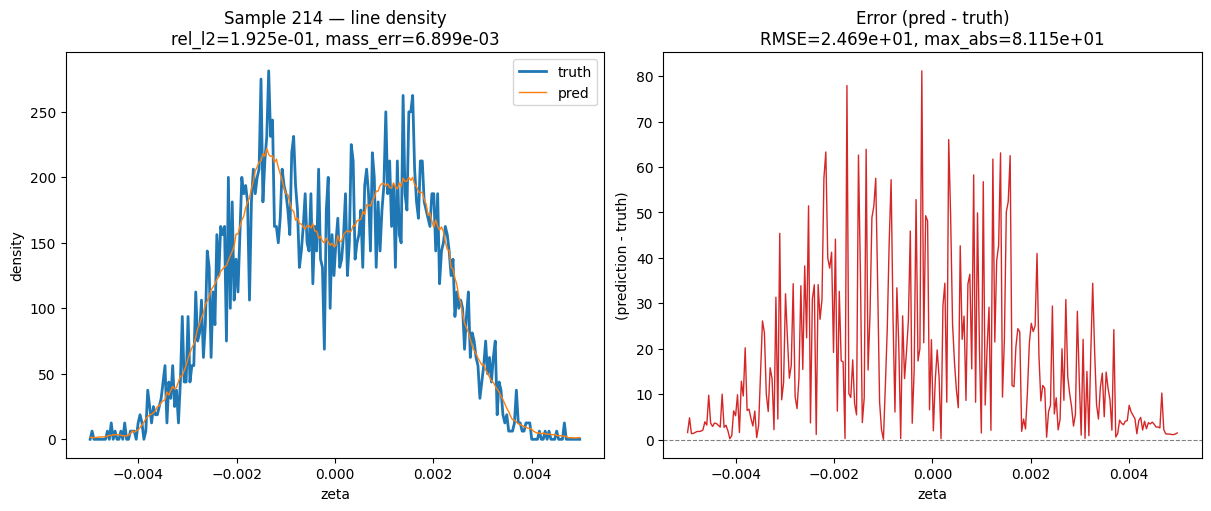

In [ ]:
idx_random = np.random.randint(0, data["Y_lambda"].shape[0])

plot_density_truth_vs_pred(sample_idx=idx_random)

In [ ]:
# load dataset (adjust path if needed)
path = "./data/neural/xsuite_neural_dataset.npz"   # or "/data/neural/xsuite_neural_dataset.npz"
data = load_npz(path)   # uses the notebook's helper; or: data = dict(np.load(path, allow_pickle=True))

print("keys:", sorted(data.keys()))
for k in sorted(data.keys()):
    v = data[k]
    if isinstance(v, np.ndarray):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
    else:
        print(f"  {k}: type={type(v)}")